In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

# load data
df = pd.read_csv("data.csv")

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [2]:
drug_cols = ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06']

df_long = df.melt(
    id_vars=['datum','Year','Month','Weekday Name'],
    value_vars=drug_cols,
    var_name='ATC',
    value_name='quantity'
)

df_long.head()

,datum,Year,Month,Weekday Name,ATC,quantity
0,1/2/2014,2014,1,Thursday,M01AB,0.0
1,1/3/2014,2014,1,Friday,M01AB,8.0
2,1/4/2014,2014,1,Saturday,M01AB,2.0
3,1/5/2014,2014,1,Sunday,M01AB,4.0
4,1/6/2014,2014,1,Monday,M01AB,5.0


In [3]:
# Q.1
# What are the total sales quantities for each drug category (ATC code)?
atc_sales = (
    df_long.groupby("ATC")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

atc_sales

ATC
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
Name: quantity, dtype: float64

In [4]:
# Q.2
# Which individual drug brands have the highest total sales?
atc_sales.head()

ATC
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
Name: quantity, dtype: float64

In [5]:
# Q.3
# Which three drugs have the highest sales in January 2015, July 2016, September 2017.
def top_drugs(year, month):
    result = (
        df_long[(df_long["Year"] == year) &
                (df_long["Month"] == month)]
        .groupby("ATC")["quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )
    print(result)

top_drugs(2015,1)
top_drugs(2016,7)
top_drugs(2017,9)

ATC
N02BE    1044.24
N05B      463.00
R03       177.25
Name: quantity, dtype: float64
ATC
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
Name: quantity, dtype: float64
ATC
N02BE    863.75
N05B     223.00
R03      139.00
Name: quantity, dtype: float64


In [6]:
# Q.4
# Which drug has sold the most often in 2017?
sales_2017 = (
    df_long[df_long["Year"] == 2017]
    .groupby("ATC")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

sales_2017.head(1)

ATC
N02BE    9258.804833
Name: quantity, dtype: float64

In [7]:
# Q.5
# Which drug category has the highest average daily sales?
avg_sales = (
    df_long.groupby("ATC")["quantity"]
    .mean()
    .sort_values(ascending=False)
)

avg_sales

ATC
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
Name: quantity, dtype: float64

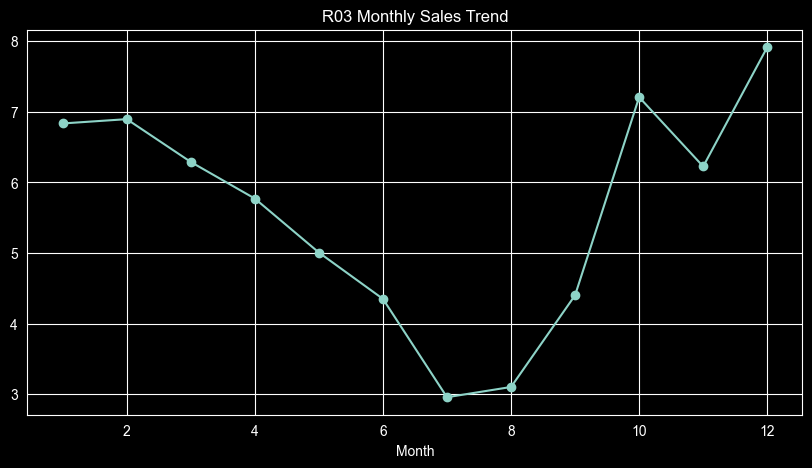

In [8]:
# Q.6
# Are respiratory drugs (R03) sold more during specific months?
r03 = df_long[df_long["ATC"] == "R03"]

monthly = r03.groupby("Month")["quantity"].mean()

monthly.plot(marker="o")
plt.title("R03 Monthly Sales Trend")
plt.show()

In [9]:
df.to_csv("cleaned_data.csv")

In [10]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

In [ ]:
df.rename(columns={
    "datum": "Date",
    "M01AB": "AntiInflammatory_Derivatives_Sales",
    "M01AE": "PropionicAcid_Derivatives_Sales",
    "N02BA": "SalicylicAcid_Analgesics_Sales",
    "N02BE": "Anilide_Analgesics_Sales",
    "N05B": "Anxiolytics_Sales",
    "N05C": "Hypnotics_Sedatives_Sales",
    "R03": "AntiAsthma_COPD_Sales",
    "R06": "Antihistamines_Sales",
    "Weekday Name": "Weekday"
}, inplace=True)